# Phase 2 — Exploratory Data Analysis
## Healthcare AI System

**Input:**  `outputs/model_table.csv` — 25,000 rows, 20 columns  
**Output:** Engineered `model_table.csv` ready for Phase 3 Modeling

## EDA Philosophy: What Architects Look For

A data scientist asks: *"What does the data look like?"*  
An architect asks: *"What will this data do to my model?"*

These are four questions every architect answers **before** touching a model:

**1. Are the labels meaningful?**  
If labels are random, no model can learn them. Period.

**2. Is there class imbalance?**  
Imbalance causes models to ignore minority classes entirely — called class collapse.

**3. Which features have real signal?**  
Correlation tells us where to focus feature engineering effort.

**4. Are outliers errors or reality?**  
In healthcare, extreme values are often the most important rows.

The answers to these four questions shape every modeling decision we make in Phase 3.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [5]:
# Load model_table
df = pd.read_csv('../outputs/model_table.csv')
print(df.shape)
df.head()

(25000, 20)


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,3993,9,M,Hyderabad,HealthPlus,1,2025-10-18,684,2025-01-20,General,ICU,5.79,Low,137,684,36721.68,36721.68,Paid,19.0,2025-08-15
1,76,59,M,Delhi,HealthPlus,0,2025-07-09,1412,2025-01-20,General,ER,34.80,Medium,109,1412,8365.47,4189.20,Pending,26.0,2025-11-14
2,3393,43,M,Hyderabad,HealthPlus,0,2025-07-10,1510,2025-01-20,ICU,ICU,31.37,Medium,135,1510,16529.35,0.00,Rejected,7.0,2025-04-24
3,1998,29,M,Bangalore,MediCareX,1,2025-04-22,1549,2025-01-20,Cardiology,ER,20.88,Medium,179,1549,61827.63,61827.63,Paid,1.0,2025-10-17
4,3500,38,M,Hyderabad,CareOne,1,2025-08-02,2275,2025-01-20,Orthopedics,ICU,4.97,Low,107,2275,5860.51,4897.65,Pending,28.0,2025-08-05


In [7]:
# Convert date columns to datetime format
df["registration_date"] = pd.to_datetime(df["registration_date"], errors='coerce')
df["billing_date"] = pd.to_datetime(df["billing_date"], errors='coerce')
df["visit_date"] = pd.to_datetime(df["visit_date"], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000256,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

First thing we always check — what is missing and why.  
Not all nulls are data errors. Some are business logic.

In [11]:
# Overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [12]:
# Focus on key columns for EDA
df[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

### Step 2 — Business Logic Validation

Three checks before we touch any model.  
We are validating that the data makes **business sense** — not just statistical sense.

In [13]:
# Check 1 - Paid claims should always have an approved amount > 0
df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(817, 20)

In [14]:
# Check 2 - Payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [21]:
# Check 3 - LOS hours should be non-negative
print(df[df["length_of_stay_hours"] < 0].shape)
print((df["length_of_stay_hours"] < 0).sum())

(0, 20)
0


### Step 3 — Distribution Analysis

We look at every important column — categorical and numeric.  
Goal: understand the shape of our data before building any model.

In [22]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


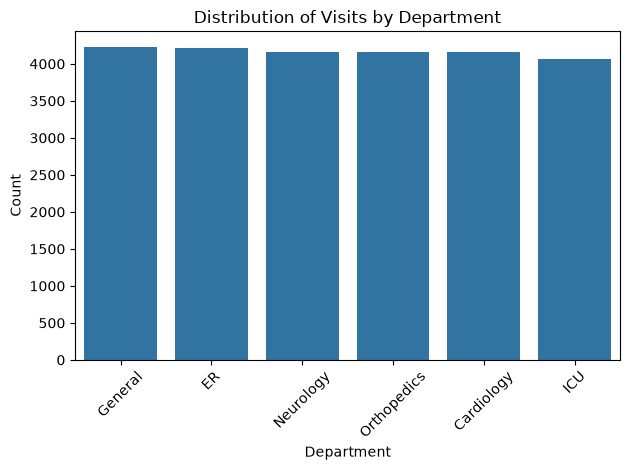

In [ ]:
# Visit distribution by department
sns.countplot(x="department", data=df, order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Visits by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

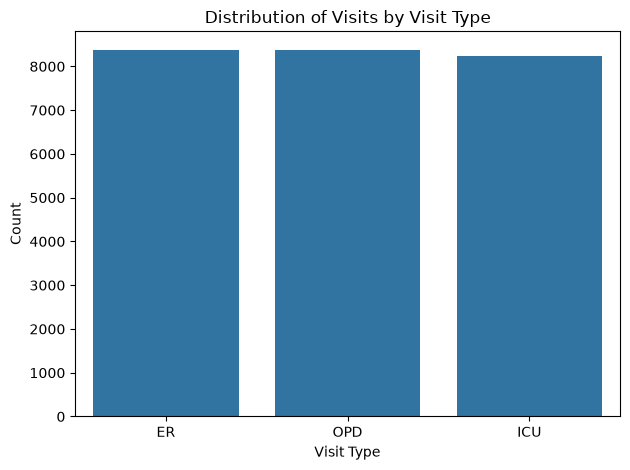

In [25]:
# Visit distribution by visit type
sns.countplot(x="visit_type", data=df, order=df["visit_type"].value_counts().index)
plt.title("Distribution of Visits by Visit Type")
plt.xlabel("Visit Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

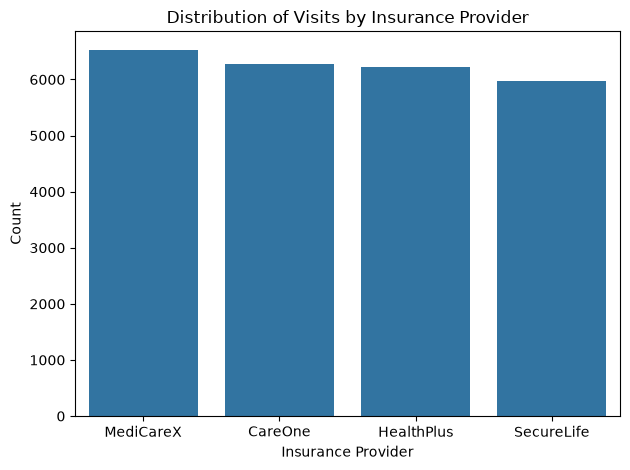

In [26]:
# Visit distribution by insurance provider
sns.countplot(x="insurance_provider", data=df, order=df["insurance_provider"].value_counts().index)
plt.title("Distribution of Visits by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

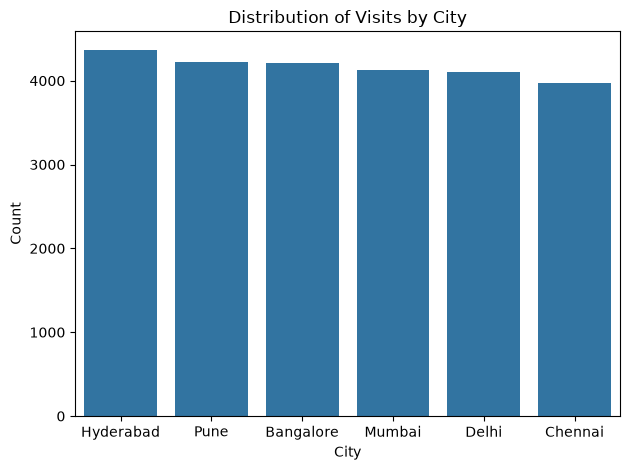

In [27]:
# Visit distribution by city
sns.countplot(x="city", data=df, order=df["city"].value_counts().index)
plt.title("Distribution of Visits by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()